In [61]:
import sys
print(sys.executable)

C:\Projects\uczenie_glembokie_projekt\.venv\Scripts\python.exe


In [101]:
import glob
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import json, time
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [63]:
# import kagglehub

# path = kagglehub.dataset_download("cantonioupao/oxford-flower-17categories-labelled")
# print("Path to dataset files:", path)

Path to dataset files: C:\Users\natii\.cache\kagglehub\datasets\cantonioupao\oxford-flower-17categories-labelled\versions\1


In [83]:
# Wczytanie danych z folderu 17FlowerOxfordDataset
labels = []
imgs = []

# Iteracja po każdym folderze gatunku
for folder in glob.glob(f"{path}/17FlowerOxfordDataset/*/"):
    flower_name = os.path.basename(folder.rstrip(os.path.sep))
    
    # Iteracja po wszystkich obrazach JPG w folderze
    for img_path in glob.glob(folder + "*.jpg"):
        labels.append(flower_name)
        
        # Wczytanie i skalowanie obrazu
        image = keras.utils.load_img(img_path, target_size=(128, 128))
        input_arr = keras.utils.img_to_array(image)
        imgs.append(input_arr)

In [84]:
# Konwersja na numpy arrays
imgs = np.array(imgs) / 255.0  # normalizacja do zakresu [0, 1]
labels = np.array(labels)

In [85]:
print(f"Wczytano {len(imgs)} obrazów")
print(f"Liczba klas: {len(np.unique(labels))}")
print("Gatunki kwiatów:")
for l in np.unique(labels):
    print(f"  - {l}")
print(f"Kształt danych: {imgs.shape}")

Wczytano 1360 obrazów
Liczba klas: 17
Gatunki kwiatów:
  - bluebell
  - buttercup
  - coltsfoot
  - cowslip
  - crocus
  - daffodil
  - daisy
  - dandelion
  - fritillary
  - iris
  - lily of the valley
  - pansy
  - snowdrop
  - sunflower
  - tiger lily
  - tulip
  - windflower
Kształt danych: (1360, 128, 128, 3)


## Wstępna eksploracja danych


Rozkład klas:
----------------------------------------
bluebell             :  80 obrazów
buttercup            :  80 obrazów
coltsfoot            :  80 obrazów
cowslip              :  80 obrazów
crocus               :  80 obrazów
daffodil             :  80 obrazów
daisy                :  80 obrazów
dandelion            :  80 obrazów
fritillary           :  80 obrazów
iris                 :  80 obrazów
lily of the valley   :  80 obrazów
pansy                :  80 obrazów
snowdrop             :  80 obrazów
sunflower            :  80 obrazów
tiger lily           :  80 obrazów
tulip                :  80 obrazów
windflower           :  80 obrazów

Razem: 1360 obrazów
Min próbek na klasę: 80
Max próbek na klasę: 80


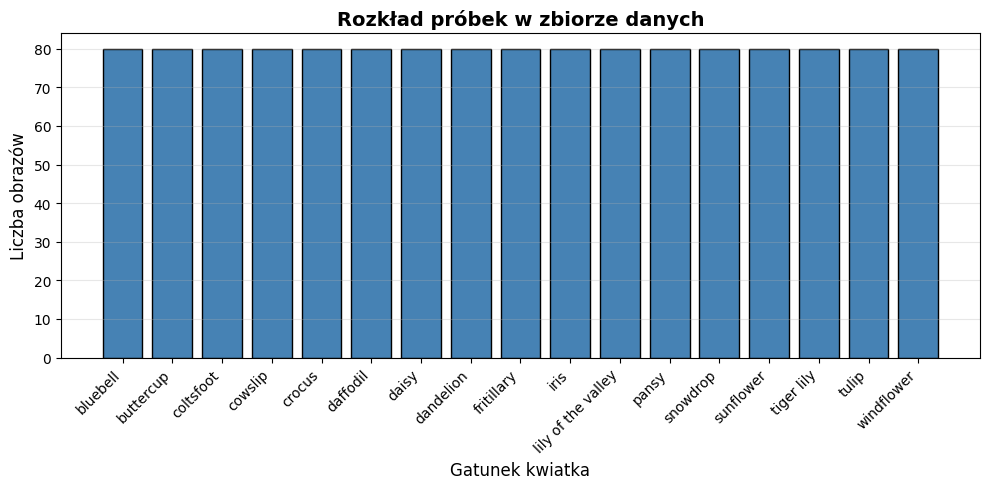

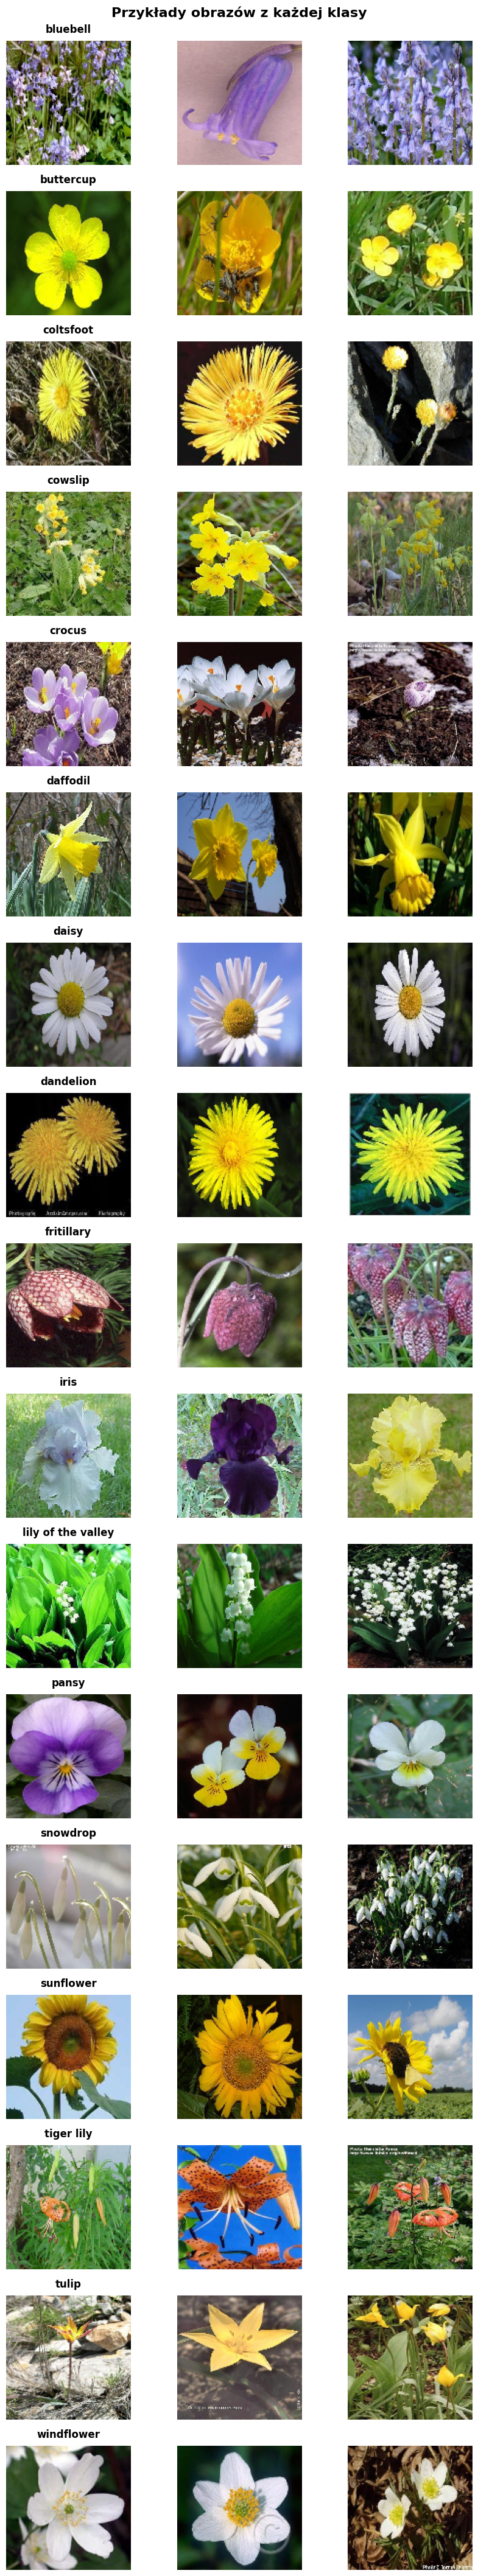

In [86]:
# Liczba próbek na klasę
class_counts = {}
for label in labels:
    class_counts[label] = class_counts.get(label, 0) + 1

print("Rozkład klas:")
print("-" * 40)
for flower, count in sorted(class_counts.items()):
    print(f"{flower:20} : {count:3} obrazów")

print(f"\nRazem: {sum(class_counts.values())} obrazów")
print(f"Min próbek na klasę: {min(class_counts.values())}")
print(f"Max próbek na klasę: {max(class_counts.values())}")

# Wizualizacja rozkładu klas
plt.figure(figsize=(10, 5))
flowers = sorted(class_counts.keys())
counts = [class_counts[f] for f in flowers]

plt.bar(flowers, counts, color='steelblue', edgecolor='black')
plt.xlabel('Gatunek kwiatka', fontsize=12)
plt.ylabel('Liczba obrazów', fontsize=12)
plt.title('Rozkład próbek w zbiorze danych', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Wyświetl kilka obrazów z każdej klasy
n_classes = len(np.unique(labels))
n_samples_per_class = 3

fig, axes = plt.subplots(
    n_classes,
    n_samples_per_class,
    figsize=(3 * n_samples_per_class, 2.5 * n_classes),
    # dpi=
)

for class_idx, flower_name in enumerate(sorted(class_counts.keys())):
    # Znajdź indeksy obrazów dla danej klasy
    class_indices = np.where(labels == flower_name)[0]
    # Losowo wybierz kilka obrazów
    rng = np.random.default_rng(42)
    selected_indices = rng.choice(class_indices, n_samples_per_class, replace=False)

    for sample_idx, img_idx in enumerate(selected_indices):
        ax = axes[class_idx, sample_idx]
        ax.imshow(imgs[img_idx])
        ax.axis('off')
        
        if sample_idx == 0:
            ax.set_title(
                flower_name,
                fontsize=12,
                fontweight='bold',
                pad=10
            )

plt.suptitle('Przykłady obrazów z każdej klasy', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [96]:
le = LabelEncoder()
y_int = le.fit_transform(labels)          # (N,) 0..16
y = keras.utils.to_categorical(y_int)     # (N,17)

#train 70%
#val 15%
#test 15%
#zachowanie proporcji klas przy dzieleniu na podzbiory
X_tmp, X_test, y_tmp, y_test, y_int_tmp, y_int_test = train_test_split(
    imgs, y, y_int, #, y, idx
    test_size=0.15,
    random_state=42,
    stratify=y_int
)

# z pozostałych 85% robisz val = 15% całości => 0.15/0.85 = 0.176470...
val_ratio = 0.15 / 0.85

X_tmp, X_test, y_tmp, y_test, y_int_tmp, y_int_test = train_test_split(
    imgs, y, y_int,
    test_size=0.15,
    random_state=42,
    stratify=y_int,
    shuffle=True
)

print(f"Podział danych:",
      f"TRAIN: {X_train.shape}",
    f"VAL:   {X_val.shape}",
    f"TEST:  {X_test.shape}",
    sep='\n')

Podział danych:
TRAIN: (952, 128, 128, 3)
VAL:   (204, 128, 128, 3)
TEST:  (204, 128, 128, 3)


## Budowa modelu CNN


In [115]:
def build_cnn(input_shape, n_classes,
              base_filters=32, n_blocks=3, dense_units=128,
              dropout_conv=0.0, dropout_dense=0.5,
              use_batchnorm=True):
    inp = layers.Input(shape=input_shape)
    x = inp

    for b in range(n_blocks):
        filters = base_filters * (2**b)

        x = layers.Conv2D(filters, 3, padding="same", use_bias=not use_batchnorm)(x)
        if use_batchnorm: x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.Conv2D(filters, 3, padding="same", use_bias=not use_batchnorm)(x)
        if use_batchnorm: x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.MaxPooling2D()(x)

        if dropout_conv and dropout_conv > 0:
            x = layers.SpatialDropout2D(dropout_conv)(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units)(x)
    if use_batchnorm: x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    if dropout_dense and dropout_dense > 0:
        x = layers.Dropout(dropout_dense)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)
    return models.Model(inp, out)

In [123]:
def train_one_run(run_dir, config, X_train, y_train, X_val, y_val, input_shape, n_classes):
    os.makedirs(run_dir, exist_ok=True)

    model = build_cnn(
        input_shape=input_shape,
        n_classes=n_classes,
        base_filters=config["base_filters"],
        n_blocks=config["n_blocks"],
        dense_units=config["dense_units"],
        dropout_conv=config["dropout_conv"],
        dropout_dense=config["dropout_dense"],
        use_batchnorm=config["use_batchnorm"]
    )

    optimizer = make_optimizer(config["optimizer"], config["lr"])
    model.compile(
        optimizer=optimizer,
        loss=config["loss"],
        metrics=[
            "accuracy",
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")
        ]
    )

    train_datagen = ImageDataGenerator(
        rotation_range=config["aug_rotation"],
        width_shift_range=config["aug_shift"],
        height_shift_range=config["aug_shift"],
        zoom_range=config.get("aug_zoom", 0.1),
        horizontal_flip=config["aug_hflip"],
        fill_mode="nearest"
    )
    # train_datagen = ImageDataGenerator()   # brak rotacji/shift/zoom/flip

    val_datagen = ImageDataGenerator()

    train_gen = train_datagen.flow(X_train, y_train, batch_size=config["batch_size"], shuffle=True)
    val_gen = val_datagen.flow(X_val, y_val, batch_size=config["batch_size"], shuffle=False)

    ckpt_path = os.path.join(run_dir, "best_model.keras")
    checkpoint_cb = ModelCheckpoint(
        ckpt_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1
    )

    reduce_lr_cb = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    earlystop_cb = EarlyStopping(
        monitor="val_accuracy", mode="max",
        patience=config["patience"], restore_best_weights=True, verbose=1
    )

    t0 = time.time()
    history = model.fit(
        train_gen,
        epochs=config["epochs"],
        validation_data=val_gen,
        callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb],
        verbose=1
    )
    elapsed = time.time() - t0

    # history.json (bezpieczny zapis)
    hist_dict = {k: [float(x) for x in v] for k, v in history.history.items()}
    with open(os.path.join(run_dir, "history.json"), "w") as f:
        json.dump(hist_dict, f, indent=2)

    # config.json
    with open(os.path.join(run_dir, "config.json"), "w") as f:
        json.dump(config, f, indent=2)

    # summary (best wg val_accuracy)
    hist = pd.DataFrame(hist_dict)
    best_idx = hist["val_accuracy"].idxmax()

    summary = {
        **config,
        "best_epoch": int(best_idx + 1),
        "best_val_loss": float(hist.loc[best_idx, "val_loss"]),
        "best_val_acc": float(hist.loc[best_idx, "val_accuracy"]),
        "best_val_top3": float(hist.loc[best_idx, "val_top3_acc"]),
        "train_loss_at_best": float(hist.loc[best_idx, "loss"]),
        "train_acc_at_best": float(hist.loc[best_idx, "accuracy"]),
        "seconds": float(elapsed),
        "run_dir": run_dir
    }

    with open(os.path.join(run_dir, "summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    return summary


In [128]:
from itertools import product

def fmt(v):
    if isinstance(v, float):
        return f"{v:g}".replace(".", "p")
    return str(v).replace(" ", "_")

def run_experiments(X_train, y_train, X_val, y_val, input_shape, n_classes, base_out="runs"):
    os.makedirs(base_out, exist_ok=True)

    base = dict(
        epochs=50,            
        loss="categorical_crossentropy",
        patience=10,
        seed=42,

        base_filters=32,
        n_blocks=3,
        dense_units=128,
        use_batchnorm=True,

        aug_rotation=20,
        aug_shift=0.1,
        aug_hflip=True,
        aug_zoom=0.1
    )

    grid = {
        "dropout_dense": [0.3, 0.5],
        "dropout_conv":  [0.0, 0.1],
        "optimizer":     ["adam"],
        "lr":            [1e-4, 5e-5],
        "batch_size":    [16, 32]
    }

    keys = list(grid.keys())
    summaries = []

    for i, values in enumerate(product(*[grid[k] for k in keys]), start=1):
        config = base.copy()
        config.update(dict(zip(keys, values)))

        run_name = f"run_{i:03d}_" + "_".join([f"{k}-{fmt(config[k])}" for k in keys])
        run_dir = os.path.join(base_out, run_name)

        print(f"\n=== {run_name} ===")
        summary = train_one_run(run_dir, config, X_train, y_train, X_val, y_val, input_shape, n_classes)
        summaries.append(summary)

        out_csv = os.path.join(base_out, "results.csv")
        df = pd.DataFrame([summary])
        df.to_csv(out_csv, mode="a", header=not os.path.exists(out_csv), index=False)

    results = pd.DataFrame(summaries).sort_values("best_val_acc", ascending=False)
    results.to_csv(os.path.join(base_out, "results_sorted.csv"), index=False)
    return results


In [ ]:
print("input_shape:", input_shape)
print("n_classes:", n_classes)
assert n_classes == len(np.unique(np.argmax(y_train, axis=1))), "Mismatch in number of classes!"

input_shape = X_train.shape[1:]  
n_classes = y_train.shape[1]       

results = run_experiments(X_train, y_train, X_val, y_val, input_shape, n_classes)
cols = ["best_val_acc", "best_val_top3", "best_val_loss",
        "optimizer", "lr", "batch_size", "dropout_conv", "dropout_dense"]
print(results[cols].head(10))

input_shape: (128, 128, 3)
n_classes: 17

=== run_001_dropout_dense-0p3_dropout_conv-0_optimizer-adam_lr-0p0001_batch_size-16 ===
Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.0760 - loss: 3.0410 - top3_acc: 0.2875
Epoch 1: val_accuracy improved from None to 0.05882, saving model to runs\run_001_dropout_dense-0p3_dropout_conv-0_optimizer-adam_lr-0p0001_batch_size-16\best_model.keras

Epoch 1: finished saving model to runs\run_001_dropout_dense-0p3_dropout_conv-0_optimizer-adam_lr-0p0001_batch_size-16\best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 428ms/step - accuracy: 0.1282 - loss: 2.7968 - top3_acc: 0.3655 - val_accuracy: 0.0588 - val_loss: 2.8891 - val_top3_acc: 0.1765 - learning_rate: 1.0000e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.3210 - loss: 2.1833 - top3_acc: 0.5910
Epoch 2: val_accuracy did not improve from 0.05882
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 402ms/step - accuracy: 0.3088 - loss: 2.1908 - top3_acc: 0.6019 - val_accuracy: 0.

In [109]:
pred = model.predict(X_val, batch_size=32)
pred_cls = np.argmax(pred, axis=1)
true_cls = np.argmax(y_val, axis=1)

print("Unique predicted classes:", np.unique(pred_cls, return_counts=True))
print("Unique true classes:", np.unique(true_cls, return_counts=True))

vals, cnts = np.unique(np.argmax(y_val, axis=1), return_counts=True)
print(dict(zip(vals, cnts)))


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step
Unique predicted classes: (array([ 2,  7,  9, 11, 13, 14]), array([34,  2, 63, 20, 39, 46]))
Unique true classes: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]), array([12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]))
{np.int64(0): np.int64(12), np.int64(1): np.int64(12), np.int64(2): np.int64(12), np.int64(3): np.int64(12), np.int64(4): np.int64(12), np.int64(5): np.int64(12), np.int64(6): np.int64(12), np.int64(7): np.int64(12), np.int64(8): np.int64(12), np.int64(9): np.int64(12), np.int64(10): np.int64(12), np.int64(11): np.int64(12), np.int64(12): np.int64(12), np.int64(13): np.int64(12), np.int64(14): np.int64(12), np.int64(15): np.int64(12), np.int64(16): np.int64(12)}


Kształt filtrów: (3, 3, 3, 64)


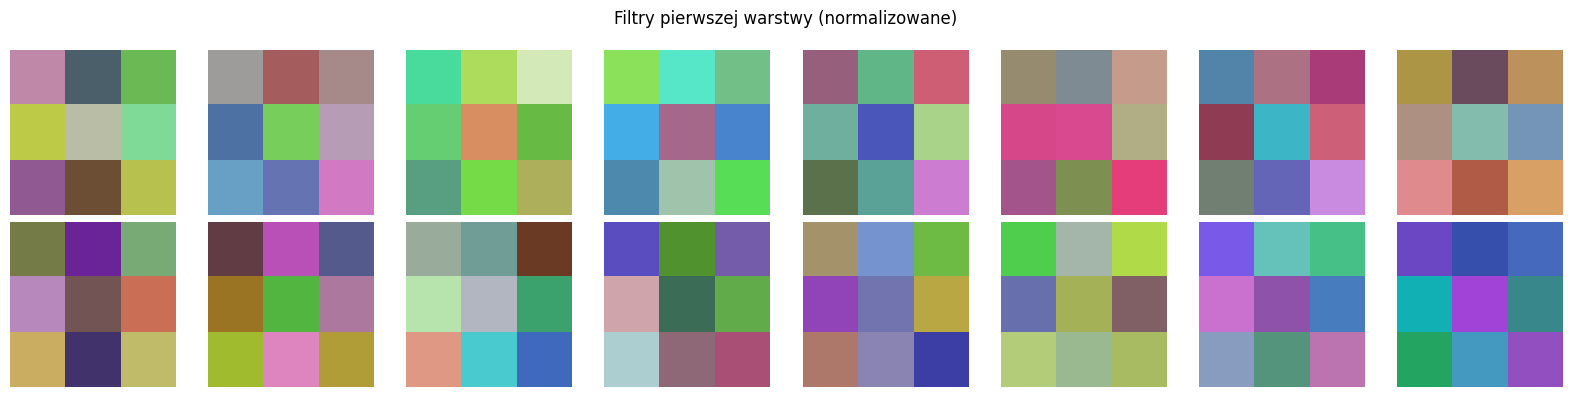

In [44]:
# Wizualizacja filtrów pierwszej warstwy

# Znajdź pierwszą warstwę Conv2D
conv_layer = None
for l in model.layers:
    if isinstance(l, klayers.Conv2D):
        conv_layer = l
        break

if conv_layer is None:
    print("Nie znaleziono warstwy Conv2D w modelu")
else:
    filters, biases = conv_layer.get_weights()
    print("Kształt filtrów:", filters.shape)

    # Normalizacja filtrów do zakresu [0,1]
    f_min, f_max = filters.min(), filters.max()
    filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)

    # Liczba filtrów do wyświetlenia
    n_filters = min(filters_norm.shape[-1], 16)
    n_cols = 8
    n_rows = int(np.ceil(n_filters / n_cols))

    plt.figure(figsize=(n_cols * 2, n_rows * 2))

    for i in range(n_filters):
        f = filters_norm[:, :, :, i]
        ax = plt.subplot(n_rows, n_cols, i+1)
        if f.shape[2] == 3:
            plt.imshow(f)
        else:
            plt.imshow(f[:, :, 0], cmap='gray')
        plt.axis('off')

    plt.suptitle('Filtry pierwszej warstwy (normalizowane)')
    plt.tight_layout()
    plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.7598 - loss: 0.8620

Ewaluacja na zbiorze testowym:
loss: 0.8620
compile_metrics: 0.7598
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step

Classification report:
              precision    recall  f1-score   support

    bluebell       0.79      0.85      0.81        13
   buttercup       0.33      0.43      0.38         7
     cowslip       0.86      0.46      0.60        13
      crocus       0.67      0.57      0.62        14
    daffodil       0.38      0.38      0.38         8
       daisy       0.86      0.92      0.89        13
   dandelion       0.80      0.80      0.80        30
  fritillary       0.90      0.82      0.86        11
        iris       0.71      0.71      0.71        14
       pansy       1.00      0.82      0.90        11
    snowdrop       0.77      0.94      0.85        18
   sunflower       0.79      1.00      0.88        11
  tiger lily       0.77      1.00      0.87        10
       tulip       0.73      0.69     

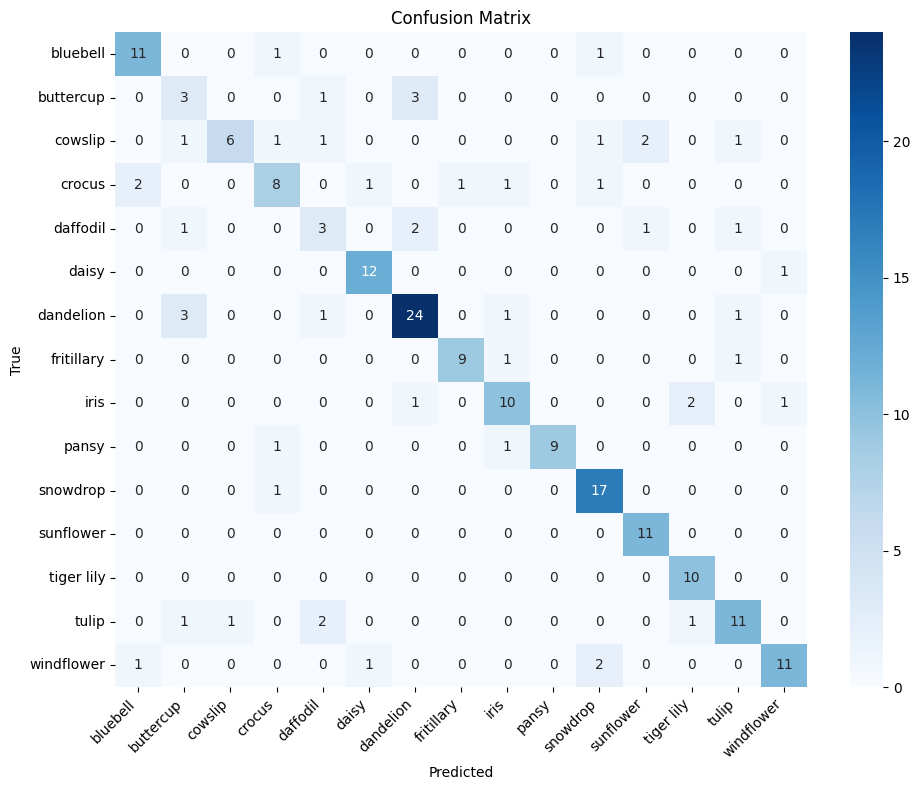


Wyniki zapisane do test_report.json


In [45]:
# Ocena na zbiorze testowym
# Podstawowa ewaluacja
results = model.evaluate(X_test, y_test, batch_size=batch_size)
print('\nEwaluacja na zbiorze testowym:')
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

# Opcjonalnie: classification_report i confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predykcje i prawdziwe etykiety (numeryczne)
y_pred = model.predict(X_test)
pred_labels = np.argmax(y_pred, axis=1)
true_labels = np.argmax(y_test, axis=1)

print('\nClassification report:')
print(classification_report(true_labels, pred_labels, target_names=le.classes_))

# Macierz pomyłek
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Zapis wyników do pliku
import json
report = classification_report(true_labels, pred_labels, target_names=le.classes_, output_dict=True)
with open('test_report.json', 'w') as f:
    json.dump({'evaluation': dict(zip(model.metrics_names, results)), 'classification_report': report}, f)
print('\nWyniki zapisane do test_report.json')

Liczba błędnych klasyfikacji: 49 / 204
Procent błędów: 24.02%


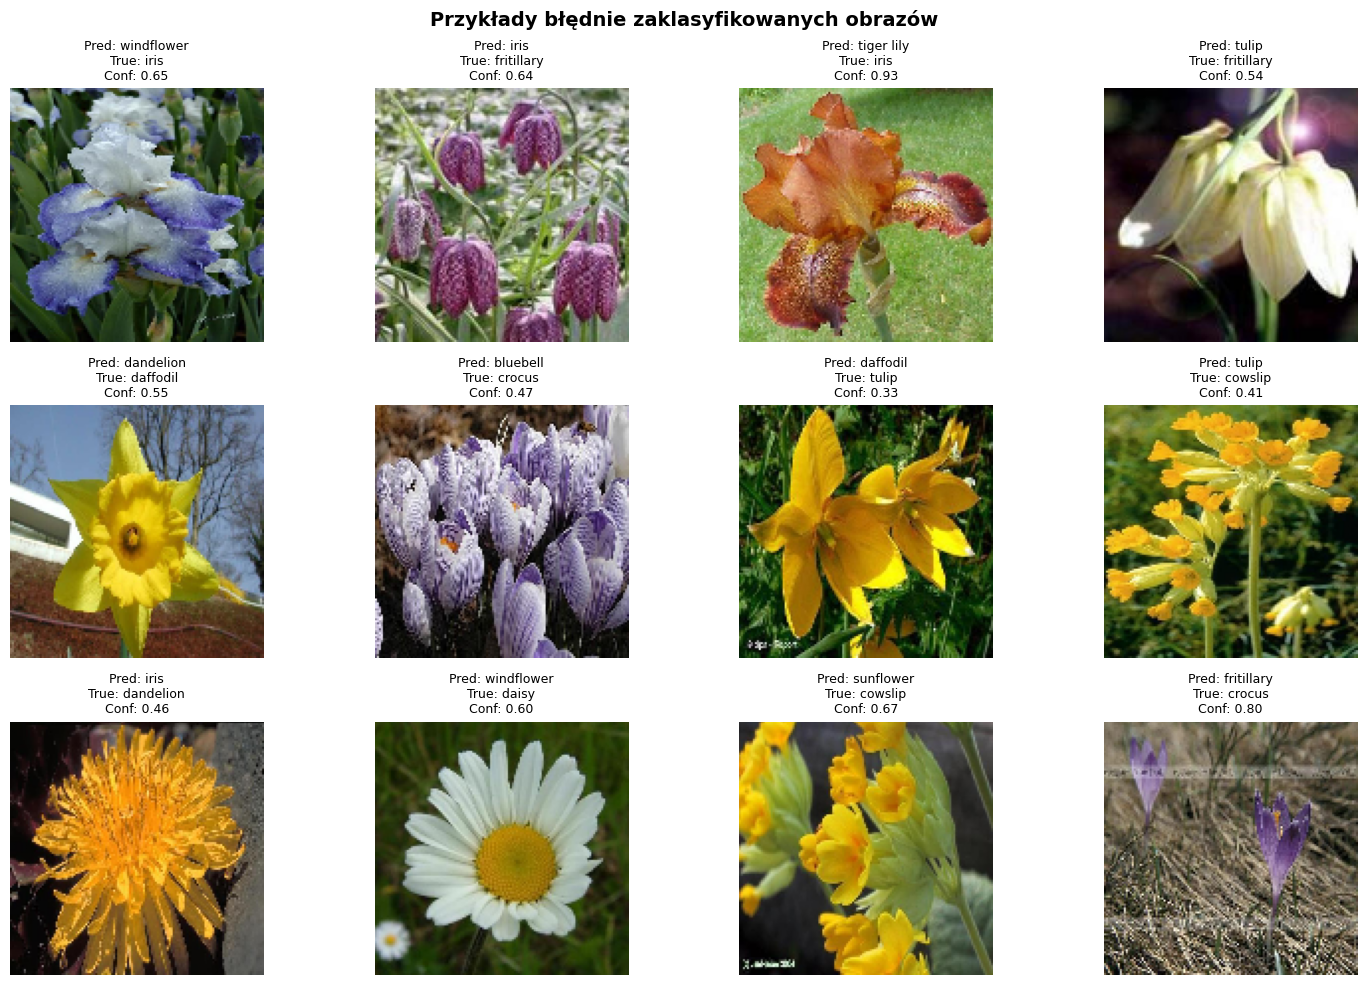

In [46]:
# Przykłady błędnych klasyfikacji
wrong_idx = np.where(pred_labels != true_labels)[0]

print(f"Liczba błędnych klasyfikacji: {len(wrong_idx)} / {len(X_test)}")
print(f"Procent błędów: {len(wrong_idx) / len(X_test) * 100:.2f}%")

if len(wrong_idx) > 0:
    plt.figure(figsize=(15, 10))
    n_samples = min(len(wrong_idx), 12)  # Wyświetlaj max 12 przykładów
    
    for i, idx in enumerate(wrong_idx[:n_samples]):
        plt.subplot(3, 4, i+1)
        plt.imshow(X_test[idx])
        pred_name = le.inverse_transform([pred_labels[idx]])[0]
        true_name = le.inverse_transform([true_labels[idx]])[0]
        pred_conf = np.max(y_pred[idx])
        
        plt.title(f"Pred: {pred_name}\nTrue: {true_name}\nConf: {pred_conf:.2f}", fontsize=9)
        plt.axis('off')
    
    plt.suptitle('Przykłady błędnie zaklasyfikowanych obrazów', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Brak błędnych klasyfikacji na zbiorze testowym!")